In [73]:
import math

In [74]:
# example dataset
# letj's say we have a dataset with two classes, A and B
# Suppose in a dataset of 10 elements, 4 are of classes A and 6 are of class B

# Number of elements in each class
n_A = 4
n_B = 6
total = n_A + n_B

In [75]:
# let's calculate the proportion
p_A = n_A / total
p_B = n_B / total

# print the proportion 
print('Preportion Of A', p_A)
print('Preportion of B', p_B)

Preportion Of A 0.4
Preportion of B 0.6


In [76]:
# Entropy calculate 
# Entropy is a  measure of uncertainity

entropy = p_A * math.log2(p_A) - p_B * math.log2(p_B)
print('Entropy', entropy)

Entropy -0.08659188145522112


In [77]:
# Gini Impurity
# Gini impurity is a measure of misclassification
gini = 1 - p_A**2 - p_B**2

print(gini)

0.48


In [78]:
# Information Gain
# Assuming a split on some feature divides the dataset into two sunsets
# subset 1: 2 elements of A, 3 of B
# sunset 2: 2 elements of A, 3 of B
# Entropy and size for each subset

n_1_A, n_1_B = 2,3 
n_2_A, n_2_B = 2,3 

p_1_A = n_1_A / (n_1_A + n_1_B)
p_1_B = n_1_B / (n_1_A + n_1_B)
entropy_1 = p_1_A * math.log2(p_1_A) - p_1_B * math.log2(p_1_B) if p_1_A and p_1_B else 0

p_2_A = n_2_A / (n_2_A + n_2_B)
p_2_B = n_2_B / (n_2_A + n_2_B)
entropy_2 = p_2_A * math.log2(p_2_A) - p_2_B * math.log2(p_2_B) if p_2_A and p_2_B else 0

# calculating the information gain
info_gain = entropy - ((n_1_A + n_1_B) / total * entropy_1 + (n_2_A + n_2_B) / total * entropy_2)
print("Information Gain: ", info_gain)


Information Gain:  0.0


# Decision Tree 

In [79]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

In [80]:
# load the data
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [81]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [82]:
# drop the dick column
df.drop('deck', axis = 1 , inplace = True)

# impute the missing value of age and fare using median 
imputer = SimpleImputer(strategy = 'median')
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])

# now impute the missing value of embarked and embark_town using mode
imputer = SimpleImputer(strategy = 'most_frequent')
df[['embarked', 'embark_town']] = imputer.fit_transform(df[['embarked', 'embark_town']])

In [83]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [86]:
# import the categorical and object variables using for loop and labelencoder
le = LabelEncoder()
for col in df.select_dtypes(include=['category', 'object']):
    df[col] = le.fit_transform(df[col])


In [87]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [91]:
# split the data into X and y
X = df.drop('survived', axis =1)
y = df['survived']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )

In [92]:
# create and train the model with prediction
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# predict the model
y_predict = model.predict(X_test)

[[105   0]
 [  0  74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(50.722222222222214, 0.5, 'True')

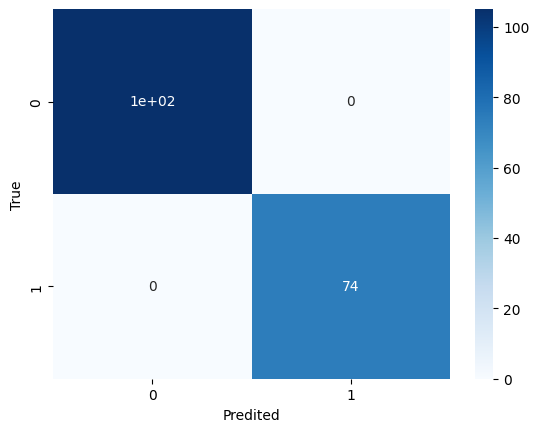

In [93]:
# evaluate the model
print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test, y_predict))

# plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, cmap = 'Blues')
plt.xlabel('Predited')
plt.ylabel('True')

In [100]:
# save the model
from sklearn.tree import export_graphviz
export_graphviz(model, out_file='./saved_models/tree.dot', feature_names = X.columns, filled=True, rounded=True)